In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv("/content/drive/MyDrive/320 files/merged.csv")

data['Timestamp'] = pd.to_datetime(data['Timestamp'])

data = data.dropna(subset=['Total Score', 'Max Points'])
data = data[data['Max Points'] > 0]

data['grade_pct'] = 100 * data['Total Score'] / data['Max Points']

def pct_to_letter(p):
    if p >= 90:
        return 'A'
    elif p >= 80:
        return 'B'
    elif p >= 70:
        return 'C'
    elif p >= 60:
        return 'D'
    else:
        return 'F'

data['letter_grade'] = data['grade_pct'].apply(pct_to_letter)
data['pass_fail'] = data['letter_grade'].apply(lambda g: 1 if g in ['A', 'B', 'C'] else 0)

drop_cols = [
    'Timestamp',
    'Total Score',
    'Max Points',
    'grade_pct',
    'letter_grade',
    'pass_fail',
    "I wanted the extra credit but just put down random responses (you'll still get the extra credit if you say yes)"
]

X = data.drop(columns=[c for c in drop_cols if c in data.columns])


X = pd.get_dummies(X, drop_first=True)

X = X.fillna(X.mean(numeric_only=True))


y_pass = data['pass_fail'].values
y_letter = data['letter_grade'].values
y_reg = data['grade_pct'].values

X_train, X_test, y_pass_train, y_pass_test, y_letter_train, y_letter_test, y_reg_train, y_reg_test = \
    train_test_split(X, y_pass, y_letter, y_reg, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Part One:
Logistic Regression accuracy: 0.684
KNN (k=5) accuracy: 0.632
Decision Tree accuracy: 0.737




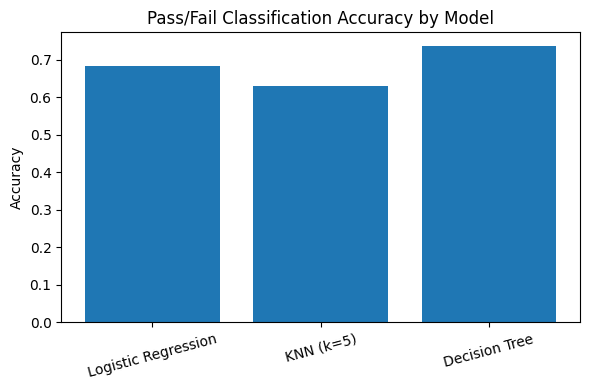

In [ ]:
print("\nPart One:")

classifiers_pf = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

pf_results = {}

for name, model in classifiers_pf.items():
    model.fit(X_train_scaled, y_pass_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_pass_test, y_pred)
    pf_results[name] = acc
    print(f"{name} accuracy: {acc:.3f}")

print("\n")
# Simple bar chart for Part 1
plt.figure(figsize=(6, 4))
plt.bar(pf_results.keys(), pf_results.values())
plt.ylabel("Accuracy")
plt.title("Pass/Fail Classification Accuracy by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Part Two:
Logistic Regression accuracy: 0.368
Random Forest accuracy: 0.474
KNN (k=5) accuracy: 0.211




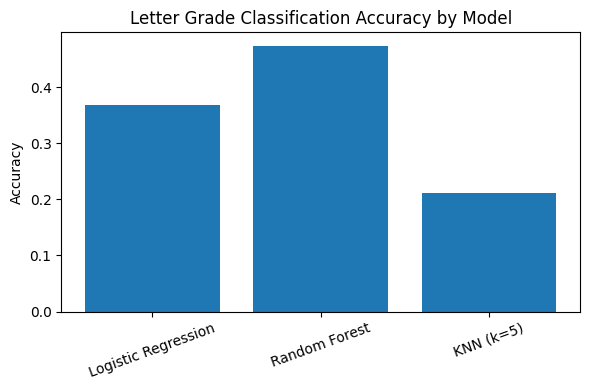

In [ ]:
print("\nPart Two:")

classifiers_letter = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=50),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

letter_results = {}

for name, model in classifiers_letter.items():
    model.fit(X_train_scaled, y_letter_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_letter_test, y_pred)
    letter_results[name] = acc
    print(f"{name} accuracy: {acc:.3f}")
print("\n")

plt.figure(figsize=(6, 4))
plt.bar(letter_results.keys(), letter_results.values())
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.title("Letter Grade Classification Accuracy by Model")
plt.tight_layout()
plt.show()



Part 3:
Linear Regression MAE: 9.86 percentage points




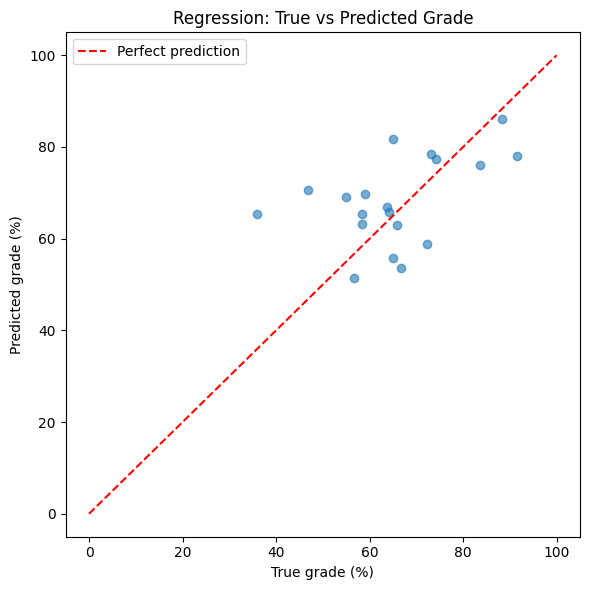

In [ ]:
print("\nPart 3:")

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_reg_train)
y_reg_pred = reg_model.predict(X_test_scaled)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
print(f"Linear Regression MAE: {mae:.2f} percentage points")
print("\n")

plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel("True grade (%)")
plt.ylabel("Predicted grade (%)")
plt.title("Regression: True vs Predicted Grade")
plt.legend()
plt.tight_layout()
plt.show()